# Mô hình dự đoán `is_canceled` — Random Forest v1.1

Phiên bản **v1.1** mở rộng từ v1: thêm 3 biến số và điều chỉnh **ngưỡng phân loại = 0,35** (thay vì 0,5 mặc định).

| Biến | Kiểu | Xử lý |
|------|------|--------|
| `deposit_type`, `market_segment`, `country`, `distribution_channel`, `customer_type`, `hotel` | Phân loại | One-Hot Encoding |
| `lead_time` | Số nguyên | Passthrough |
| `total_of_special_requests` | Số nguyên | Passthrough |
| `previous_cancellations` | Số nguyên | Passthrough |

**Ngưỡng dự đoán:** `P(hủy) >= 0.35` → dự đoán **Hủy** (ưu tiên Recall, bắt thêm booking có nguy cơ hủy).

**Nguyên tắc chống Data Leakage:**
1. Chỉ đọc 9 feature + biến mục tiêu — **không** nạp `reservation_status`, `revenue`, `Occupancy_Rate`, `RevPAR`, ...
2. `train_test_split` **trước** mọi bước tiền xử lý.
3. `OneHotEncoder` chỉ `fit` trên tập train (qua `Pipeline` + `ColumnTransformer`).
4. Gộp category hiếm dựa trên tần suất train.

In [1]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
TEST_SIZE = 0.2
DATA_BASENAME = "hotel_bookings"
VERSION_PATTERN = re.compile(rf"^{DATA_BASENAME}_v(\d+)\.csv$", re.IGNORECASE)

# Các cột leakage — KHÔNG được đưa vào mô hình
LEAKAGE_COLUMNS = {
    "reservation_status",       # gần như nhãn của hủy (Canceled = 100%)
    "reservation_status_date",    # ngày ghi nhận trạng thái — sau khi hủy
    "revenue",                    # = adr × total_nights × (1 - is_canceled)
    "Occupancy_Rate",
    "RevPAR",
}

PREDICTION_THRESHOLD = 0.35

CATEGORICAL_FEATURES = [
    "deposit_type",
    "market_segment",
    "country",
    "distribution_channel",
    "customer_type",
    "hotel",
]
NUMERIC_FEATURES = [
    "lead_time",
    "total_of_special_requests",
    "previous_cancellations",
]
FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERIC_FEATURES
TARGET_COLUMN = "is_canceled"


def _data_search_roots() -> list[Path]:
    notebook_dir = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
    search_roots = [
        notebook_dir / "data",
        notebook_dir,
        notebook_dir.parent / "data",
        notebook_dir.parent,
        notebook_dir.parent.parent,
        Path.cwd() / "data",
        Path.cwd(),
    ]
    path = Path.cwd()
    for _ in range(6):
        search_roots.extend([path / "data", path])
        path = path.parent

    seen, roots = set(), []
    for root in search_roots:
        try:
            root = root.resolve()
        except OSError:
            continue
        if root not in seen:
            seen.add(root)
            roots.append(root)
    return roots


def find_latest_versioned_data_file() -> Path:
    candidates: list[tuple[int, Path]] = []
    for root in _data_search_roots():
        if not root.is_dir():
            continue
        for file_path in root.glob(f"{DATA_BASENAME}_v*.csv"):
            if "test" in file_path.name.lower():
                continue
            match = VERSION_PATTERN.match(file_path.name)
            if match:
                candidates.append((int(match.group(1)), file_path.resolve()))

    if not candidates:
        raise FileNotFoundError(f"Không tìm thấy file '{DATA_BASENAME}_v*.csv'")

    latest_version, latest_path = max(candidates, key=lambda item: item[0])
    print(f"Chọn file v{latest_version} mới nhất: {latest_path.name}")
    return latest_path


csv_path = find_latest_versioned_data_file()
print(f"Đang đọc: {csv_path}")

# Chỉ đọc feature + target — tránh nạp nhầm cột leakage
df = pd.read_csv(
    csv_path,
    usecols=FEATURE_COLUMNS + [TARGET_COLUMN],
)

print(f"Số booking: {len(df):,}")
print(f"Tỷ lệ hủy: {df[TARGET_COLUMN].mean() * 100:.2f}%")
print(f"\nCột leakage đã loại: {sorted(LEAKAGE_COLUMNS)}")
df.head()

Chọn file v5 mới nhất: hotel_bookings_v5.csv
Đang đọc: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
Số booking: 82,811
Tỷ lệ hủy: 28.12%

Cột leakage đã loại: ['Occupancy_Rate', 'RevPAR', 'reservation_status', 'reservation_status_date', 'revenue']


,hotel,is_canceled,lead_time,country,market_segment,distribution_channel,previous_cancellations,deposit_type,customer_type,total_of_special_requests
0,Resort Hotel,0,342,PRT,Direct,Direct,0,No Deposit,Transient,0
1,Resort Hotel,0,737,PRT,Direct,Direct,0,No Deposit,Transient,0
2,Resort Hotel,0,7,GBR,Direct,Direct,0,No Deposit,Transient,0
3,Resort Hotel,0,13,GBR,Corporate,Corporate,0,No Deposit,Transient,0
4,Resort Hotel,0,14,GBR,Online TA,TA/TO,0,No Deposit,Transient,1


## 1. Kiểm tra dữ liệu & chuẩn bị feature

In [2]:
# Kiểm tra missing và phân bố feature
print("=== Missing values ===")
print(df[FEATURE_COLUMNS + [TARGET_COLUMN]].isna().sum())

for col in CATEGORICAL_FEATURES:
    print(f"\n=== {col} ===")
    if col == "country":
        print(df[col].value_counts().head(10))
        print(f"Số quốc gia duy nhất: {df[col].nunique()}")
        rare = (df[col].value_counts() < 5).sum()
        print(f"Quốc gia có < 5 booking: {rare}")
    else:
        print(df[col].value_counts())

print("\n=== Biến số (describe) ===")
display(df[NUMERIC_FEATURES].describe().T)

model_df = df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
model_df["country"] = model_df["country"].fillna("Unknown").astype(str)
for col in CATEGORICAL_FEATURES:
    model_df[col] = model_df[col].astype(str)
for col in NUMERIC_FEATURES:
    model_df[col] = model_df[col].fillna(0).astype(int)

X = model_df[FEATURE_COLUMNS]
y = model_df[TARGET_COLUMN].astype(int)

print(f"\nKích thước X: {X.shape}")
print(f"Phân bố y: {y.value_counts().to_dict()}")

=== Missing values ===
deposit_type                 0
market_segment               0
country                      0
distribution_channel         0
customer_type                0
hotel                        0
lead_time                    0
total_of_special_requests    0
previous_cancellations       0
is_canceled                  0
dtype: int64

=== deposit_type ===
deposit_type
No Deposit    81767
Non Refund      963
Refundable       81
Name: count, dtype: int64

=== market_segment ===
market_segment
Online TA        50391
Offline TA/TO    12860
Direct           11351
Groups            3690
Corporate         3678
Complementary      619
Aviation           220
Undefined            2
Name: count, dtype: int64

=== country ===
country
PRT    25299
GBR     9921
FRA     8464
ESP     6973
DEU     5109
ITA     2900
IRL     2893
BEL     2022
BRA     1936
NLD     1864
Name: count, dtype: int64
Số quốc gia duy nhất: 178
Quốc gia có < 5 booking: 65

=== distribution_channel ===
distribution_channe

,count,mean,std,min,25%,50%,75%,max
lead_time,82811.0,78.491819,84.327945,0.0,11.0,48.0,123.0,737.0
total_of_special_requests,82811.0,0.709519,0.834496,0.0,0.0,1.0,1.0,5.0
previous_cancellations,82811.0,0.028462,0.325021,0.0,0.0,0.0,0.0,25.0



Kích thước X: (82811, 9)
Phân bố y: {0: 59527, 1: 23284}


## 2. Train / Test split (trước khi mã hóa)

Tách dữ liệu **trước** mọi bước fit encoder để tránh leakage từ tập test vào quá trình học category.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Tỷ lệ hủy train: {y_train.mean() * 100:.2f}%")
print(f"Tỷ lệ hủy test:  {y_test.mean() * 100:.2f}%")

Train: 66,248 | Test: 16,563
Tỷ lệ hủy train: 28.12%
Tỷ lệ hủy test:  28.12%


## 3. Pipeline: One-Hot + biến số → Random Forest

- **OneHotEncoder** cho biến phân loại; biến số đi **passthrough** (Random Forest không cần scale).
- `min_frequency=5`: gộp category hiếm thành `infrequent` — chỉ học từ train.
- Dự đoán nhị phân dùng ngưỡng **0,35**: `y_pred = (P(hủy) >= 0.35)`.

In [4]:
categorical_encoder = OneHotEncoder(
    handle_unknown="infrequent_if_exist",
    min_frequency=5,
    sparse_output=False,
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_encoder, CATEGORICAL_FEATURES),
        ("num", "passthrough", NUMERIC_FEATURES),
    ],
    remainder="drop",
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 4. Huấn luyện & đánh giá

In [5]:
rf_pipeline.fit(X_train, y_train)

y_proba = rf_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= PREDICTION_THRESHOLD).astype(int)

print(f"=== Classification Report (Test) — ngưỡng {PREDICTION_THRESHOLD} ===")
print(classification_report(y_test, y_pred, target_names=["Không hủy", "Hủy"]))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC (test): {roc_auc:.4f}")

cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)
print(f"\nCV ROC-AUC (5-fold, train only): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

y_pred_default = (y_proba >= 0.5).astype(int)
print(f"\n--- So sánh F1 class Hủy: ngưỡng 0.5 vs {PREDICTION_THRESHOLD} ---")
print(f"F1 @ 0.50: {f1_score(y_test, y_pred_default, pos_label=1):.4f}")
print(f"F1 @ {PREDICTION_THRESHOLD:.2f}: {f1_score(y_test, y_pred, pos_label=1):.4f}")

=== Classification Report (Test) — ngưỡng 0.35 ===
              precision    recall  f1-score   support

   Không hủy       0.95      0.47      0.63     11906
         Hủy       0.41      0.94      0.57      4657

    accuracy                           0.60     16563
   macro avg       0.68      0.70      0.60     16563
weighted avg       0.80      0.60      0.61     16563

ROC-AUC (test): 0.8305

CV ROC-AUC (5-fold, train only): 0.8294 ± 0.0036

--- So sánh F1 class Hủy: ngưỡng 0.5 vs 0.35 ---
F1 @ 0.50: 0.5999
F1 @ 0.35: 0.5695


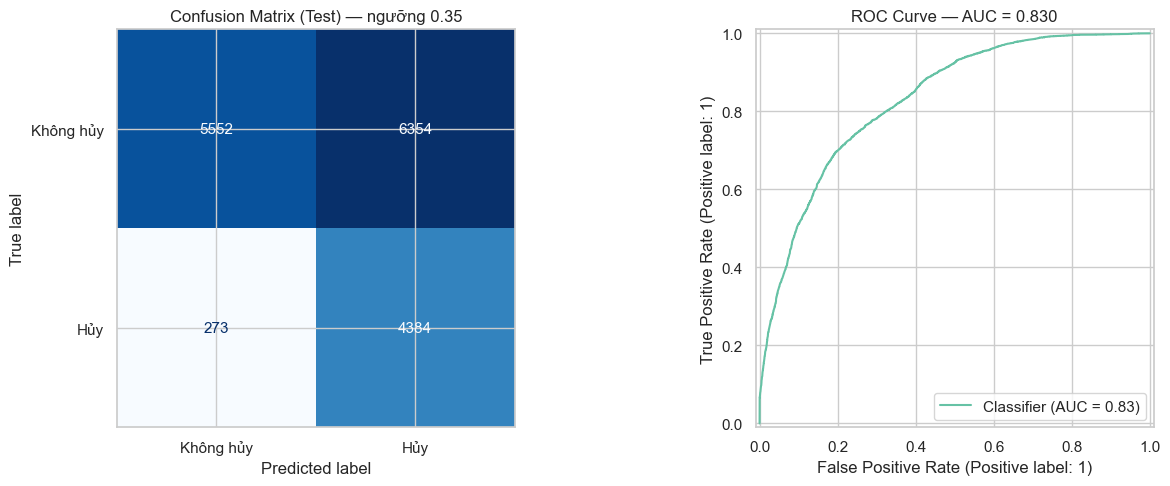

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Không hủy", "Hủy"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"Confusion Matrix (Test) — ngưỡng {PREDICTION_THRESHOLD}")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f"ROC Curve — AUC = {roc_auc:.3f}")

plt.tight_layout()
plt.show()

## 5. Phân phối xác suất dự đoán (Prediction Probability Distribution)

So sánh phân phối `P(hủy)` giữa booking **thực sự không hủy** và **thực sự hủy** trên tập test.

**Quy ước màu:** teal = Không hủy · orange = Hủy · đường đứt nét = ngưỡng **0,35** (v1.1).

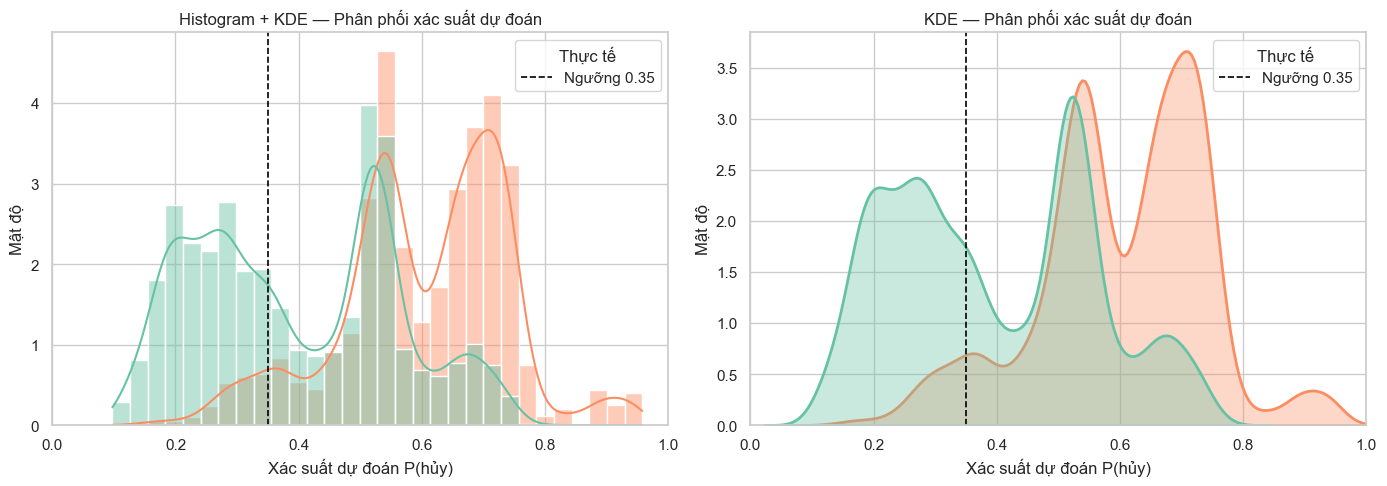

=== Thống kê P(hủy) theo nhãn thực tế (test) ===


,n,mean,median,std
actual,,,,
Không hủy,11906,0.3943,0.3702,0.1631
Hủy,4657,0.6030,0.6264,0.1376


In [7]:
proba_df = pd.DataFrame(
    {
        "probability": y_proba,
        "actual": np.where(y_test == 1, "Hủy", "Không hủy"),
    }
)

# Đảo màu Set2: teal = Không hủy, orange = Hủy (mặc định seaborn gán ngược lại)
LABEL_ORDER = ["Không hủy", "Hủy"]
LABEL_PALETTE = {"Không hủy": "#66c2a5", "Hủy": "#fc8d62"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE chồng lên nhau
sns.histplot(
    data=proba_df,
    x="probability",
    hue="actual",
    hue_order=LABEL_ORDER,
    palette=LABEL_PALETTE,
    bins=30,
    kde=True,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=axes[0],
)
axes[0].axvline(PREDICTION_THRESHOLD, color="black", linestyle="--", linewidth=1.2, label=f"Ngưỡng {PREDICTION_THRESHOLD}")
axes[0].set_xlabel("Xác suất dự đoán P(hủy)")
axes[0].set_ylabel("Mật độ")
axes[0].set_title("Histogram + KDE — Phân phối xác suất dự đoán")
axes[0].set_xlim(0, 1)
axes[0].legend(title="Thực tế")

# KDE thuần — dễ nhìn sự tách lớp
sns.kdeplot(
    data=proba_df,
    x="probability",
    hue="actual",
    hue_order=LABEL_ORDER,
    palette=LABEL_PALETTE,
    fill=True,
    common_norm=False,
    alpha=0.35,
    linewidth=2,
    ax=axes[1],
)
axes[1].axvline(PREDICTION_THRESHOLD, color="black", linestyle="--", linewidth=1.2, label=f"Ngưỡng {PREDICTION_THRESHOLD}")
axes[1].set_xlabel("Xác suất dự đoán P(hủy)")
axes[1].set_ylabel("Mật độ")
axes[1].set_title("KDE — Phân phối xác suất dự đoán")
axes[1].set_xlim(0, 1)
axes[1].legend(title="Thực tế")

plt.tight_layout()
plt.show()

# Thống kê tóm tắt
summary = (
    proba_df.groupby("actual", observed=True)["probability"]
    .agg(["count", "mean", "median", "std"])
    .rename(columns={"count": "n"})
    .reindex(LABEL_ORDER)
)
print("=== Thống kê P(hủy) theo nhãn thực tế (test) ===")
display(summary.round(4))

## 6. Feature Importance

Sau tiền xử lý, mỗi category thành cột One-Hot; biến số giữ nguyên tên. Top 20 cột quan trọng nhất.

Số cột sau One-Hot Encoding: 132

Top 20 feature quan trọng nhất:


,feature,importance
0,lead_time,0.211246
1,market_segment_Online TA,0.131848
2,country_PRT,0.109523
3,total_of_special_requests,0.099558
4,market_segment_Offline TA/TO,0.072918
5,customer_type_Transient,0.045815
6,distribution_channel_TA/TO,0.045096
7,customer_type_Transient-Party,0.031524
8,previous_cancellations,0.029587
9,deposit_type_No Deposit,0.028305


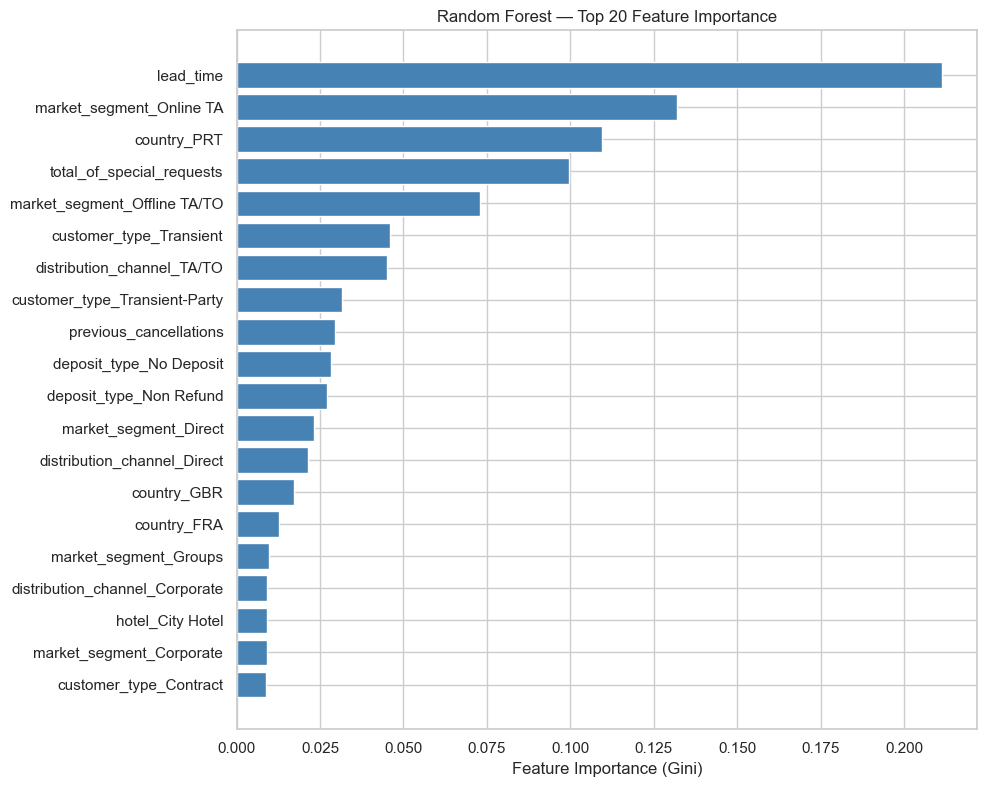


Tổng importance theo biến gốc:


,source,importance
6,market,0.247782
5,lead_time,0.211246
0,country,0.174848
8,total_of_special_requests,0.099558
1,customer,0.087741
3,distribution,0.075860
2,deposit,0.055356
7,previous_cancellations,0.029587
4,hotel,0.018022


In [8]:
preprocessor_fitted = rf_pipeline.named_steps["preprocessor"]
cat_encoder = preprocessor_fitted.named_transformers_["cat"]
cat_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES)
feature_names = np.concatenate([cat_names, np.array(NUMERIC_FEATURES, dtype=object)])
importances = rf_pipeline.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(f"Số cột sau One-Hot Encoding: {len(feature_names)}")
print("\nTop 20 feature quan trọng nhất:")
display(importance_df.head(20))

top_n = 20
plot_df = importance_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["feature"], plot_df["importance"], color="steelblue")
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title(f"Random Forest — Top {top_n} Feature Importance")
plt.tight_layout()
plt.show()

# Tổng hợp importance theo biến gốc
importance_df["source"] = importance_df["feature"].apply(
    lambda x: x if x in NUMERIC_FEATURES else x.split("_", 1)[0]
)
grouped = (
    importance_df.groupby("source", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)
print("\nTổng importance theo biến gốc:")
display(grouped)

## 7. Tóm tắt v1.1

| Bước | Cách xử lý |
|------|------------|
| Loại leakage | Không đọc `reservation_status`, `revenue`, `Occupancy_Rate`, `RevPAR`, ... |
| Phân loại | `OneHotEncoder` → cột nhị phân 0/1 |
| Biến số mới | `lead_time`, `total_of_special_requests`, `previous_cancellations` (passthrough) |
| Chống leakage | `train_test_split` trước; `Pipeline` fit chỉ trên train |
| Ngưỡng | **`P(hủy) >= 0.35`** → dự đoán Hủy |
| Mô hình | `RandomForestClassifier` (300 cây, `class_weight='balanced'`) |

**Khác v1:** thêm 3 biến số + hạ ngưỡng 0,35 để tăng Recall (bắt thêm booking hủy), đổi lại có thể tăng False Positive.